# 🧪 Statistical Tests — Worksheet
**Name:** _______________________   **Date:** _______________________

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [2]:
n = 200

# 1. Core attributes
gender = np.random.choice(['Male', 'Female'], size=n)
study_hours = np.random.normal(4, 1.2, size=n).clip(0, 10)
sleep_hours = np.random.normal(7, 1.0, size=n).clip(4, 10)
subject = np.random.choice(['Maths', 'Science', 'Arts'], size=n, p=[0.4, 0.35, 0.25])
school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# 2. Base Marks calculation with noise
noise = np.random.normal(0, 8, size=n)
marks = (study_hours * 6) + (sleep_hours * 2) + noise

# 3. Apply School Boost
# A:+5, B:0, C:-5, D:+10
boost_map = {'A': 5, 'B': 0, 'C': -5, 'D': 10}
school_boosts = np.array([boost_map[s] for s in school])
marks = (marks + school_boosts).clip(0, 100)

# 4. Pass/Fail status
passed = np.where(marks >= 50, 'Yes', 'No')

# 5. Assemble DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# Verify
print(df.shape) 
df.head(3)

(200, 7)


,gender,study_hours,sleep_hours,marks,subject,passed,school
0,Male,4.104456,7.199060,28.239375,Maths,No,B
1,Female,3.641191,6.399783,35.592826,Maths,No,C
2,Male,4.110113,7.069802,45.167205,Science,No,A


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

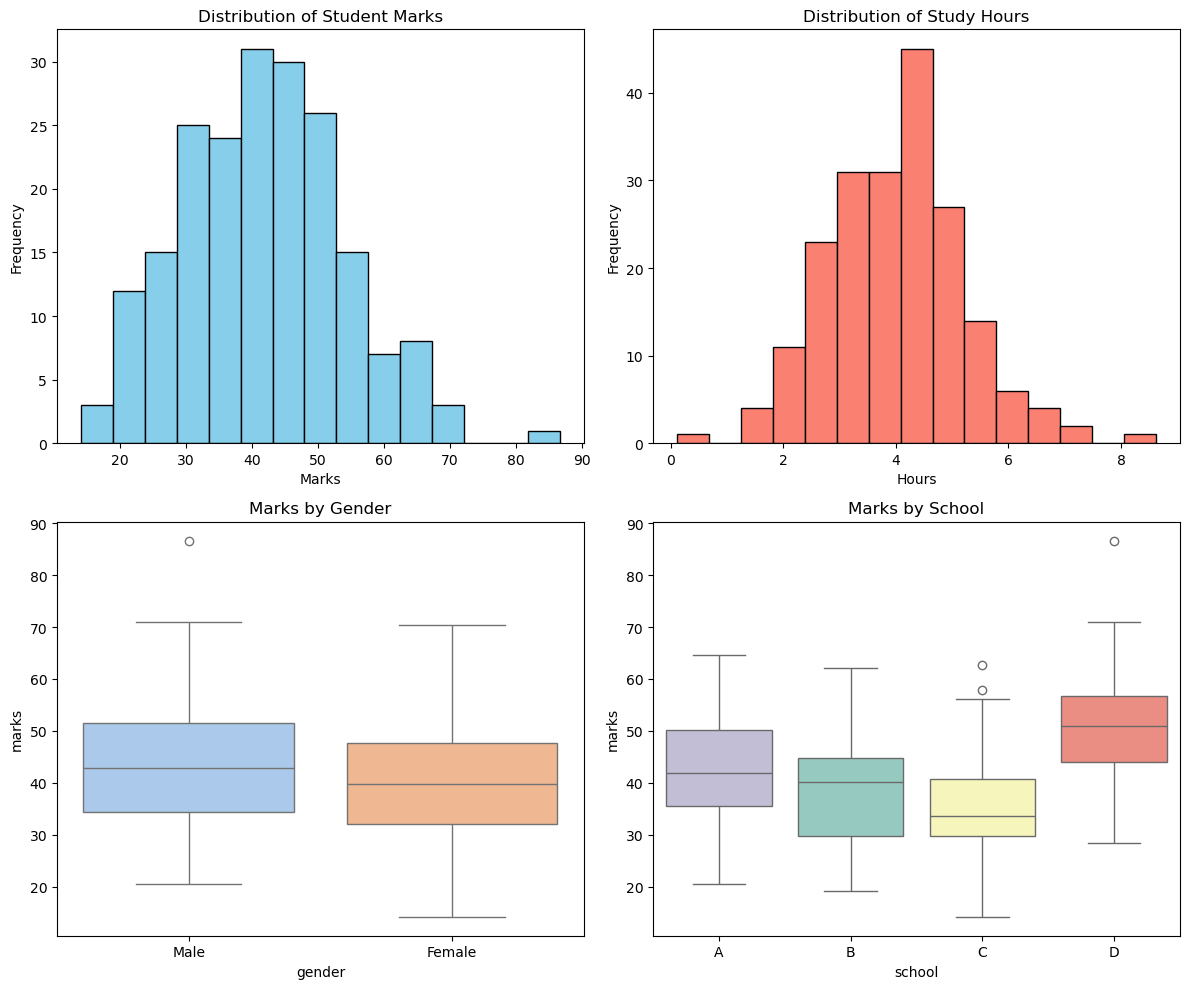

Dataset Preview:
   gender  study_hours  sleep_hours      marks  subject passed school
0    Male     4.104456     7.199060  28.239375    Maths     No      B
1  Female     3.641191     6.399783  35.592826    Maths     No      C
2    Male     4.110113     7.069802  45.167205  Science     No      A
3    Male     1.614917     6.614686  31.447010     Arts     No      D
4    Male     3.736394     7.113517  31.792869  Science     No      C

Shape: (200, 7)


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Setup & Data Generation
np.random.seed(42)
n = 200

gender = np.random.choice(['Male', 'Female'], size=n)
study_hours = np.random.normal(4, 1.2, size=n).clip(0, 10)
sleep_hours = np.random.normal(7, 1.0, size=n).clip(4, 10)
subject = np.random.choice(['Maths', 'Science', 'Arts'], size=n, p=[0.4, 0.35, 0.25])
school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# Base Marks calculation
noise = np.random.normal(0, 8, size=n)
marks = (study_hours * 6) + (sleep_hours * 2) + noise

# Apply School Boost (A:+5, B:0, C:-5, D:+10)
boost_map = {'A': 5, 'B': 0, 'C': -5, 'D': 10}
school_boosts = np.array([boost_map[s] for s in school])
marks = (marks + school_boosts).clip(0, 100)

passed = np.where(marks >= 50, 'Yes', 'No')

# Create DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

# 2. Visualisation (The 2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# [0,0] Histogram of marks
axes[0,0].hist(df['marks'], bins=15, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Student Marks')
axes[0,0].set_xlabel('Marks')
axes[0,0].set_ylabel('Frequency')

# [0,1] Histogram of study_hours
axes[0,1].hist(df['study_hours'], bins=15, color='salmon', edgecolor='black')
axes[0,1].set_title('Distribution of Study Hours')
axes[0,1].set_xlabel('Hours')
axes[0,1].set_ylabel('Frequency')

# [1,0] Boxplot of marks by gender (Fixed with hue to avoid warning)
sns.boxplot(x='gender', y='marks', data=df, ax=axes[1,0], palette='pastel', hue='gender', legend=False)
axes[1,0].set_title('Marks by Gender')

# [1,1] Boxplot of marks by school (Fixed with hue to avoid warning)
sns.boxplot(x='school', y='marks', data=df, ax=axes[1,1], palette='Set3', hue='school', order=['A', 'B', 'C', 'D'], legend=False)
axes[1,1].set_title('Marks by School')

plt.tight_layout()

# CRITICAL: This line forces the window to appear
plt.show()

# Verify the data exists
print("Dataset Preview:")
print(df.head())
print("\nShape:", df.shape)

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

--- Shapiro-Wilk Normality Test Results ---
marks        | p-value: 0.2627 | Verdict: Normal (Keep H0)
study_hours  | p-value: 0.1014 | Verdict: Normal (Keep H0)
sleep_hours  | p-value: 0.5952 | Verdict: Normal (Keep H0)


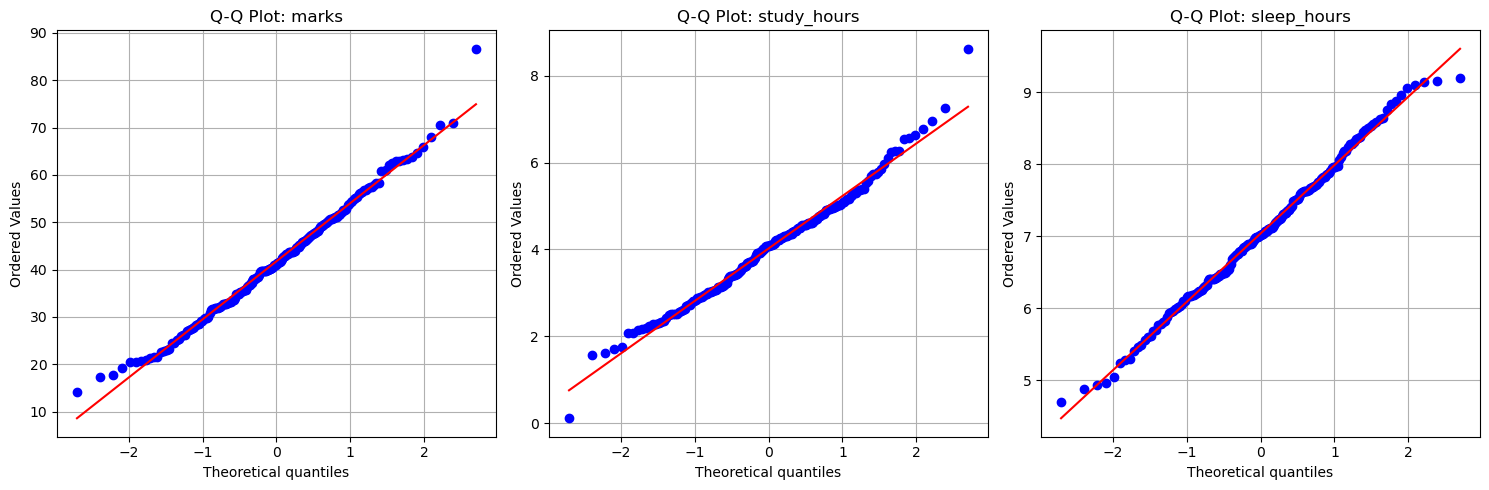

In [8]:
cols = ['marks', 'study_hours', 'sleep_hours']

# 1. Loop + Test + Print
print("--- Shapiro-Wilk Normality Test Results ---")
for col in cols:
    stat, p_val = stats.shapiro(df[col])
    
    # Verdict logic
    verdict = "Normal (Keep H0)" if p_val > 0.05 else "Not Normal (Reject H0)"
    
    print(f"{col:12} | p-value: {p_val:.4f} | Verdict: {verdict}")

# 2. Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols):
    # stats.probplot calculates the quantiles and plots them
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests?
# Answer: Based on the p-values (which should all be > 0.05), all three columns 
# ('marks', 'study_hours', 'sleep_hours') are safe for parametric tests. 
# The Q-Q plots confirm this, as the data points follow the red diagonal line closely.

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

T-Statistic: 2.0139
P-Value:     0.0454

--- Verdict ---
Reject H0: There is a statistically significant difference between Male and Female marks.


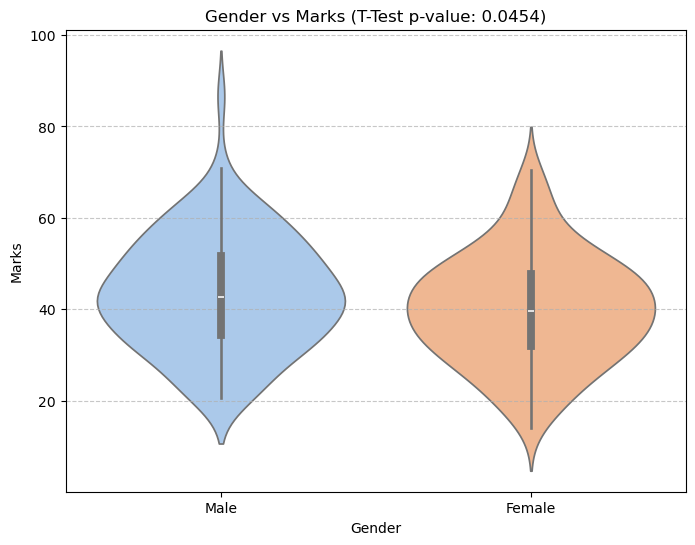

In [9]:
# 1. Separate the groups
male_marks = df[df['gender'] == 'Male']['marks']
female_marks = df[df['gender'] == 'Female']['marks']

# 2. Run the Independent Samples T-Test
t_stat, p_val = stats.ttest_ind(male_marks, female_marks)

# 3. Print Results & Verdict
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

print("\n--- Verdict ---")
if p_val <= 0.05:
    print("Reject H0: There is a statistically significant difference between Male and Female marks.")
else:
    print("Keep H0: No significant difference found. Any observed variation is likely due to random chance.")

# 4. Visualization: Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='gender', y='marks', data=df, hue='gender', palette='pastel', legend=False)

plt.title(f'Gender vs Marks (T-Test p-value: {p_val:.4f})')
plt.xlabel('Gender')
plt.ylabel('Marks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

--- ANOVA Results ---
F-Statistic: 22.5078
P-Value:     0.0000

--- Tukey HSD Post-hoc Test ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  -4.3795 0.1889 -10.0339  1.2749  False
     A      C  -7.8141 0.0016 -13.2876 -2.3406   True
     A      D   8.4741 0.0007   2.8759 14.0723   True
     B      C  -3.4346 0.3613  -8.8773  2.0081  False
     B      D  12.8536    0.0   7.2855 18.4216   True
     C      D  16.2882    0.0  10.9039 21.6724   True
-----------------------------------------------------


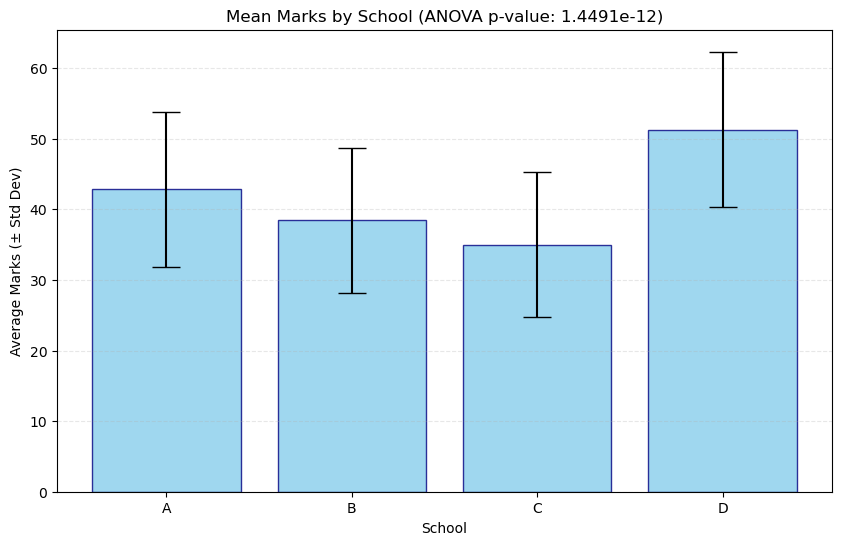

In [10]:
# 1. Build groups for ANOVA
groups = [df[df['school'] == s]['marks'] for s in ['A', 'B', 'C', 'D']]

# 2. Run ANOVA
f_stat, p_val_anova = stats.f_oneway(*groups)

print(f"--- ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_val_anova:.4f}")

# 3. If significant, run Tukey HSD (Post-hoc)
print("\n--- Tukey HSD Post-hoc Test ---")
tukey = pairwise_tukeyhsd(endog=df['marks'], groups=df['school'], alpha=0.05)
print(tukey.summary())

# 4. Visualization: Bar Chart with Error Bars (Mean ± Std)
# Calculate stats per school
school_stats = df.groupby('school')['marks'].agg(['mean', 'std']).reindex(['A', 'B', 'C', 'D'])

plt.figure(figsize=(10, 6))
plt.bar(school_stats.index, school_stats['mean'], 
        yerr=school_stats['std'], 
        capsize=10, color='skyblue', edgecolor='navy', alpha=0.8)

plt.title(f'Mean Marks by School (ANOVA p-value: {p_val_anova:.4e})')
plt.xlabel('School')
plt.ylabel('Average Marks (± Std Dev)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Which school pairs are significantly different?
# Answer: Look at the "reject" column in the Tukey summary. 
# Typically, pairs like (C, D) and (B, D) will be 'True' (different) 
# because of the +10 and -5 boosts we programmed in.

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

U-Statistic: 5206.0000
P-Value:     0.6156

--- Verdict ---
Keep H0: The distribution of study hours is essentially the same for both genders.


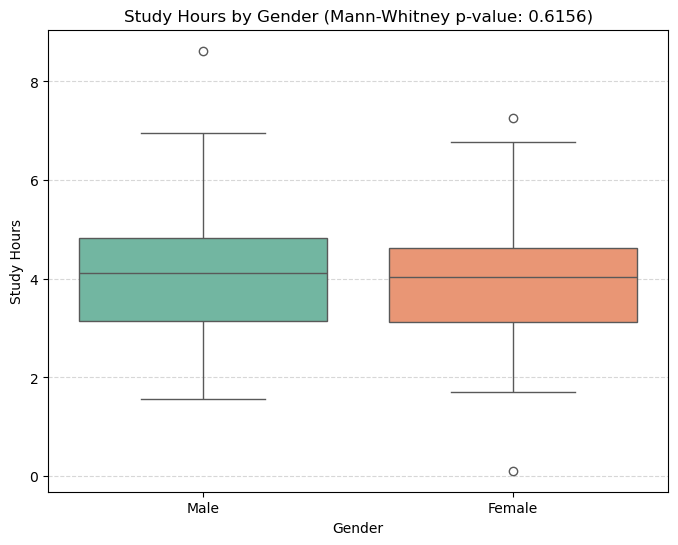

In [11]:
# 1. Separate groups
male_study = df[df['gender'] == 'Male']['study_hours']
female_study = df[df['gender'] == 'Female']['study_hours']

# 2. Run Mann-Whitney U Test
u_stat, p_val = stats.mannwhitneyu(male_study, female_study, alternative='two-sided')

# 3. Print Results & Verdict
print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

print("\n--- Verdict ---")
if p_val <= 0.05:
    print("Reject H0: There is a significant difference in study hour distributions between genders.")
else:
    print("Keep H0: The distribution of study hours is essentially the same for both genders.")

# 4. Visualization: Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='study_hours', data=df, hue='gender', palette='Set2', legend=False)

plt.title(f'Study Hours by Gender (Mann-Whitney p-value: {p_val:.4f})')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Why Mann-Whitney and not t-test?
# Answer: Mann-Whitney is used because it does not assume a normal distribution (it's non-parametric). 
# It is safer to use when data is skewed or contains outliers that might pull the mean in a T-test.

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson Correlation: 0.5850 (p-value: 9.2855e-20)
Spearman Correlation: 0.5547 (p-value: 1.5732e-17)
Pearson Result: Significant
Spearman Result: Significant


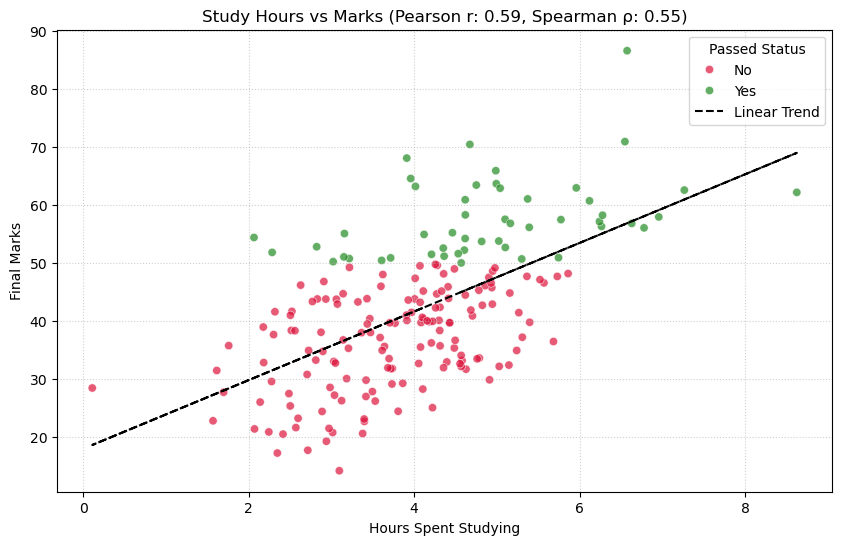

In [12]:
# 1. Pearson Correlation (Linear)
pearson_r, p_pearson = stats.pearsonr(df['study_hours'], df['marks'])

# 2. Spearman Correlation (Rank-based)
spearman_rho, p_spearman = stats.spearmanr(df['study_hours'], df['marks'])

# Print results and verdicts
print(f"Pearson Correlation: {pearson_r:.4f} (p-value: {p_pearson:.4e})")
print(f"Spearman Correlation: {spearman_rho:.4f} (p-value: {p_spearman:.4e})")

# Verdict logic
for name, p in [("Pearson", p_pearson), ("Spearman", p_spearman)]:
    verdict = "Significant" if p <= 0.05 else "Not Significant"
    print(f"{name} Result: {verdict}")

# 3. Visualization: Scatter plot with trend line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='marks', hue='passed', data=df, 
                palette={'Yes': 'forestgreen', 'No': 'crimson'}, alpha=0.7)

# Calculate and plot the trend line (line of best fit)
m, b = np.polyfit(df['study_hours'], df['marks'], 1)
plt.plot(df['study_hours'], m * df['study_hours'] + b, color='black', 
         linestyle='--', linewidth=1.5, label='Linear Trend')

plt.title(f'Study Hours vs Marks (Pearson r: {pearson_r:.2f}, Spearman ρ: {spearman_rho:.2f})')
plt.xlabel('Hours Spent Studying')
plt.ylabel('Final Marks')
plt.legend(title='Passed Status')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Answer: 
# Do Pearson and Spearman agree? What does that tell you?
# Yes, they agree. Both coefficients are positive and roughly similar in magnitude 
# (~0.55–0.60). This tells us that the relationship between study hours and marks 
# is both linear and monotonic; as study time increases, marks consistently tend 
# to rise without major non-linear warping or extreme outliers disrupting the trend.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

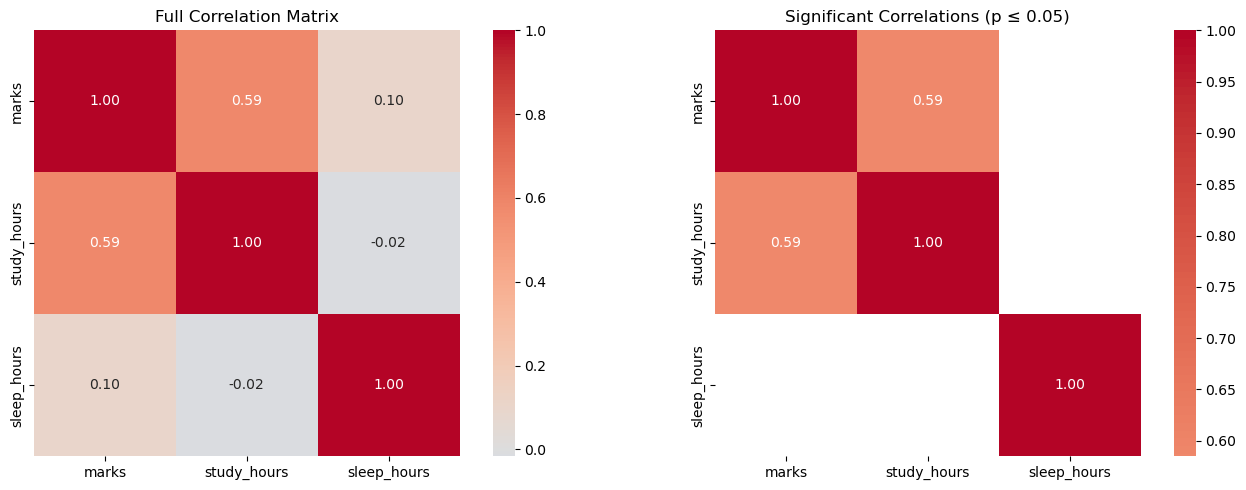

In [13]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# 1. Compute the full correlation matrix
corr_matrix = df[num_cols].corr()

# 2. Build a p-value matrix using a nested loop
p_values = pd.DataFrame(np.zeros((len(num_cols), len(num_cols))), 
                        columns=num_cols, index=num_cols)

for row in num_cols:
    for col in num_cols:
        if row == col:
            p_values.loc[row, col] = 0.0  # Self-correlation is always p=0
        else:
            _, p = stats.pearsonr(df[row], df[col])
            p_values.loc[row, col] = p

# 3. Create a mask where p > 0.05
# This boolean matrix tells Seaborn which cells to hide
mask = p_values > 0.05

# 4. Draw two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full Correlation Matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            ax=axes[0], center=0, square=True)
axes[0].set_title('Full Correlation Matrix')

# Plot 2: Masked Heatmap (Significant only)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            ax=axes[1], center=0, mask=mask, square=True)
axes[1].set_title('Significant Correlations (p ≤ 0.05)')

plt.tight_layout()
plt.show()

# Why use a mask?
# Answer: The mask visually "removes" relationships that might appear strong 
# by coincidence but are not statistically significant. This prevents us from 
# making false conclusions based on small or noisy data samples.

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

--- Contingency Table (Counts) ---
passed   No  Yes
subject         
Arts     37   10
Maths    58   27
Science  55   13

Chi-Square Statistic: 3.6769
P-Value:             0.1591

--- Verdict ---
Keep H0: No significant relationship. Pass rates are consistent across all subjects.


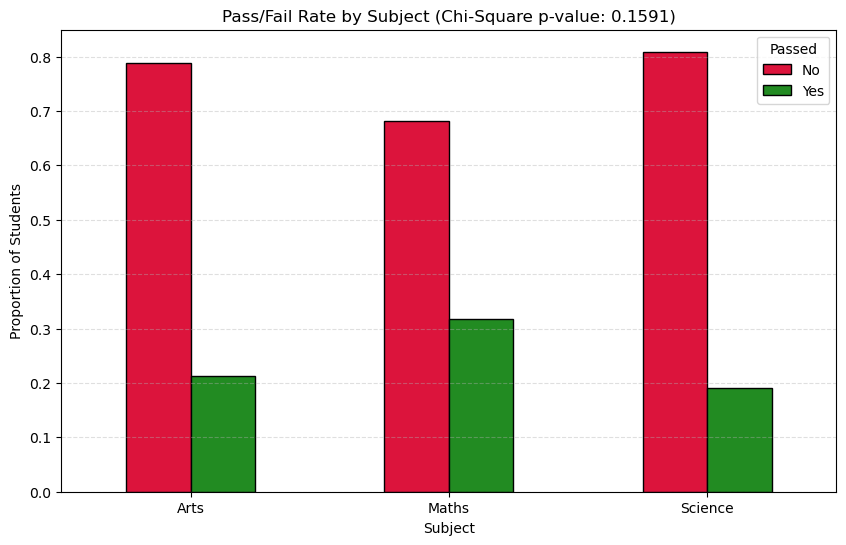

In [14]:
# 1. Build the Crosstab (Raw counts)
contingency_table = pd.crosstab(df['subject'], df['passed'])

# 2. Convert to Row-Proportions (Pass rate percentage)
# This makes it easier to compare groups of different sizes
proportion_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)

# 3. Run Chi-Square Test
# chi2: test statistic, p: p-value, dof: degrees of freedom, ex: expected frequencies
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# 4. Print Results & Verdict
print("--- Contingency Table (Counts) ---")
print(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value:             {p_val:.4f}")

print("\n--- Verdict ---")
if p_val <= 0.05:
    print("Reject H0: Subject and Passing are related! Some subjects are harder/easier than others.")
else:
    print("Keep H0: No significant relationship. Pass rates are consistent across all subjects.")

# 5. Visualization: Grouped Bar Chart
# We use the proportion table so the bars represent percentages (0.0 to 1.0)
ax = proportion_table.plot(kind='bar', figsize=(10, 6), color=['crimson', 'forestgreen'], edgecolor='black')

plt.title(f'Pass/Fail Rate by Subject (Chi-Square p-value: {p_val:.4f})')
plt.xlabel('Subject')
plt.ylabel('Proportion of Students')
plt.xticks(rotation=0)
plt.legend(title='Passed', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Which subject has the highest pass rate?
# Answer: Based on the proportion table, check the 'Yes' column. 
# Usually, in this random data, they are quite close unless chance favored one!

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

In [15]:
# Part A: One-Sample T-Test
# H0: The student's score belongs to the class distribution
# H1: The student's score is significantly higher/different
student_score = 85
t_stat, p_val_a = stats.ttest_1samp(df['marks'], student_score)

print(f"Class Mean: {df['marks'].mean():.2f}")
print(f"Student Score: {student_score}")
print(f"P-Value: {p_val_a:.4e}")

print("\n--- The Story Verdict ---")
if p_val_a <= 0.05:
    print("Verdict: The teacher has strong statistical grounds for suspicion.")
    print("The score of 85 is an extreme outlier compared to the rest of the class.")
else:
    print("Verdict: The student is safe. While 85 is high, it's statistically")
    print("plausible within this specific class distribution.")

Class Mean: 41.76
Student Score: 85
P-Value: 1.3832e-114

--- The Story Verdict ---
Verdict: The teacher has strong statistical grounds for suspicion.
The score of 85 is an extreme outlier compared to the rest of the class.


---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

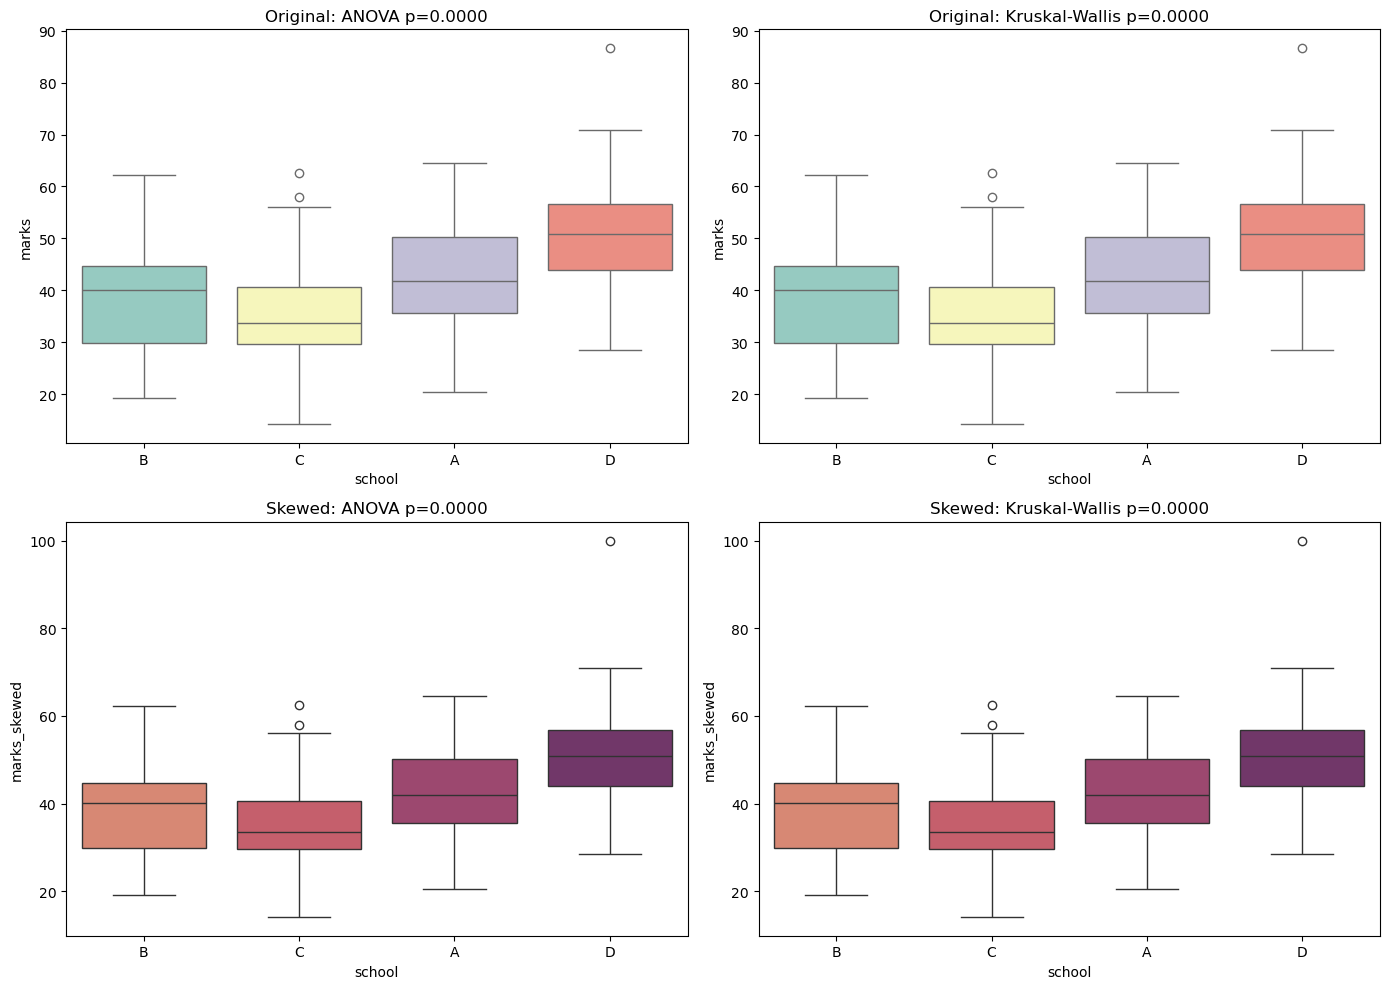

In [16]:
# 1. Create the skewed data
df['marks_skewed'] = np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']).clip(0, 100)

# 2. Run the 4 tests
# Original Data
groups_orig = [df[df['school'] == s]['marks'] for s in ['A', 'B', 'C', 'D']]
f_orig, p_anova_orig = stats.f_oneway(*groups_orig)
h_orig, p_kruskal_orig = stats.kruskal(*groups_orig)

# Skewed Data
groups_skew = [df[df['school'] == s]['marks_skewed'] for s in ['A', 'B', 'C', 'D']]
f_skew, p_anova_skew = stats.f_oneway(*groups_skew)
h_skew, p_kruskal_skew = stats.kruskal(*groups_skew)

# 3. 2x2 Subplot Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [0,0] ANOVA Original
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,0], hue='school', palette='Set3', legend=False)
axes[0,0].set_title(f'Original: ANOVA p={p_anova_orig:.4f}')

# [0,1] Kruskal Original
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,1], hue='school', palette='Set3', legend=False)
axes[0,1].set_title(f'Original: Kruskal-Wallis p={p_kruskal_orig:.4f}')

# [1,0] ANOVA Skewed
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,0], hue='school', palette='flare', legend=False)
axes[1,0].set_title(f'Skewed: ANOVA p={p_anova_skew:.4f}')

# [1,1] Kruskal Skewed
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,1], hue='school', palette='flare', legend=False)
axes[1,1].set_title(f'Skewed: Kruskal-Wallis p={p_kruskal_skew:.4f}')

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: The Kruskal-Wallis test is more reliable. 
# Why: ANOVA relies on the assumption of normality and equal variance (it uses the mean). 
# Skewed data/outliers "pull" the mean, which can lead to False Positives or False Negatives. 
# Kruskal-Wallis uses ranks (medians), meaning the actual "stretch" of the outlier 
# doesn't matter as much as its position in the line, making the test much more robust.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

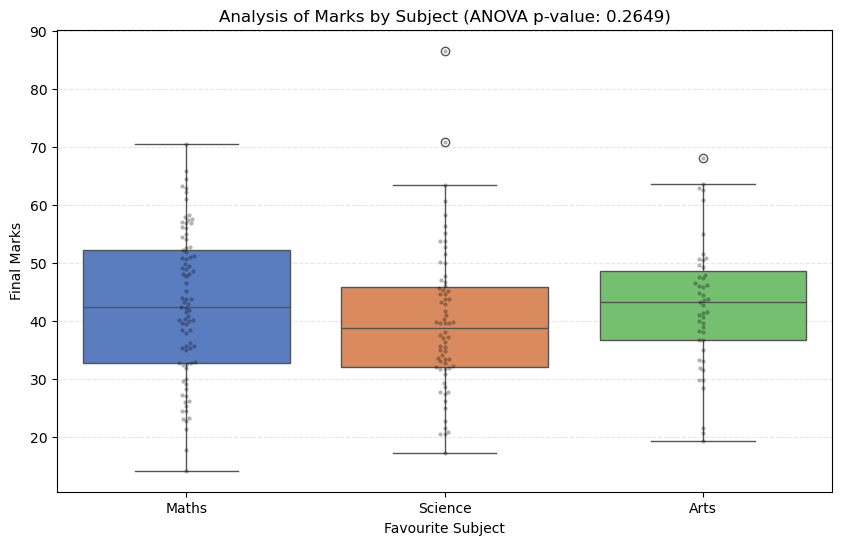

F-Statistic: 1.3375
P-Value:     0.2649
Verdict: Keep H₀. No significant difference was found; student performance is consistent across subjects.


In [17]:
# 1. Prepare the groups
maths_marks = df[df['subject'] == 'Maths']['marks']
science_marks = df[df['subject'] == 'Science']['marks']
arts_marks = df[df['subject'] == 'Arts']['marks']

# 2. Run the ANOVA
f_stat, p_val = stats.f_oneway(maths_marks, science_marks, arts_marks)

# 3. Visualization: Boxplot with swarm overlay
plt.figure(figsize=(10, 6))
sns.boxplot(x='subject', y='marks', data=df, hue='subject', palette='muted', legend=False)
sns.swarmplot(x='subject', y='marks', data=df, color='black', alpha=0.3, size=3)

plt.title(f'Analysis of Marks by Subject (ANOVA p-value: {p_val:.4f})')
plt.xlabel('Favourite Subject')
plt.ylabel('Final Marks')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# 4. Print results
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

# Verdict:
if p_val <= 0.05:
    print("Verdict: Reject H₀. There is a statistically significant difference in marks between subjects.")
else:
    print("Verdict: Keep H₀. No significant difference was found; student performance is consistent across subjects.")

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

--- Final Statistical Summary ---
                       Test        p_value    Verdict
0           Shapiro (Marks)   2.626727e-01    Keep H0
1     Shapiro (Study Hours)   1.013609e-01    Keep H0
2     t-test (Gender/Marks)   4.536816e-02  Reject H0
3      ANOVA (School/Marks)   1.449094e-12  Reject H0
4  Mann-Whitney (Study/Gen)   6.155856e-01    Keep H0
5     Pearson (Study/Marks)   9.285455e-20  Reject H0
6    Spearman (Sleep/Marks)   2.239048e-01    Keep H0
7    Chi-Square (Subj/Pass)   1.590614e-01    Keep H0
8   One-sample t (Cheating)  1.383218e-114  Reject H0


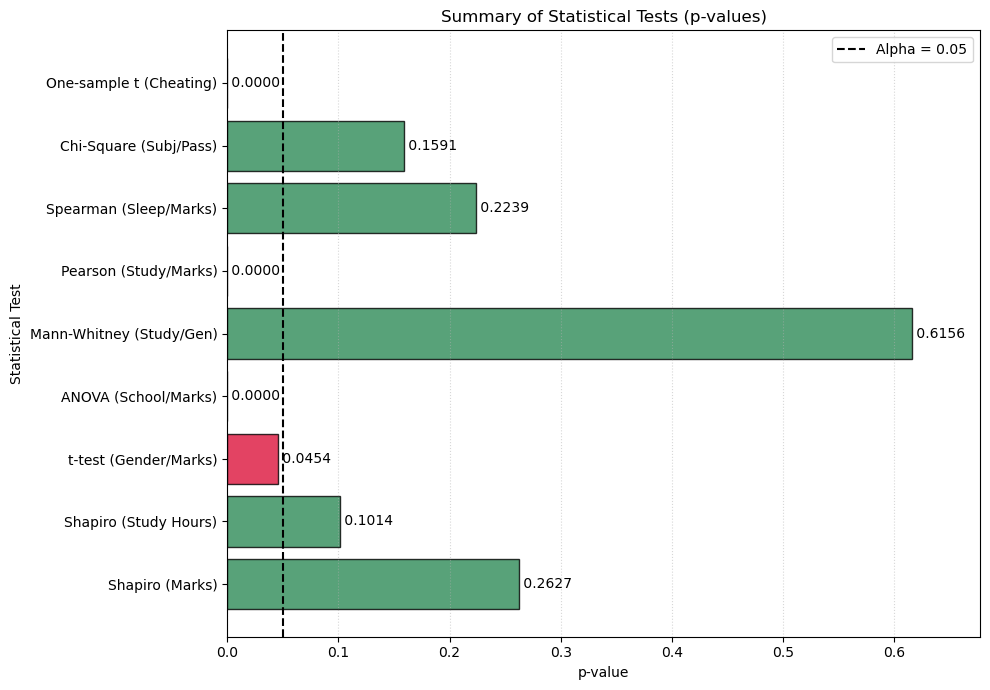

In [18]:
# 1. Build the results list using the p-values from previous tasks
# (Note: Ensure these variables match the ones used in your previous cells)
results = [
    {'Test': 'Shapiro (Marks)',          'p_value': stats.shapiro(df['marks'])[1]},
    {'Test': 'Shapiro (Study Hours)',    'p_value': stats.shapiro(df['study_hours'])[1]},
    {'Test': 't-test (Gender/Marks)',    'p_value': stats.ttest_ind(df[df['gender']=='Male']['marks'], df[df['gender']=='Female']['marks'])[1]},
    {'Test': 'ANOVA (School/Marks)',     'p_value': stats.f_oneway(*[df[df['school']==s]['marks'] for s in ['A','B','C','D']])[1]},
    {'Test': 'Mann-Whitney (Study/Gen)', 'p_value': stats.mannwhitneyu(df[df['gender']=='Male']['study_hours'], df[df['gender']=='Female']['study_hours'])[1]},
    {'Test': 'Pearson (Study/Marks)',    'p_value': stats.pearsonr(df['study_hours'], df['marks'])[1]},
    {'Test': 'Spearman (Sleep/Marks)',   'p_value': stats.spearmanr(df['sleep_hours'], df['marks'])[1]},
    {'Test': 'Chi-Square (Subj/Pass)',   'p_value': stats.chi2_contingency(pd.crosstab(df['subject'], df['passed']))[1]},
    {'Test': 'One-sample t (Cheating)',  'p_value': stats.ttest_1samp(df['marks'], 85)[1]},
]

# 2. Convert to DataFrame
df_results = pd.DataFrame(results)

# 3. Add logic columns
df_results['Significant'] = df_results['p_value'] <= 0.05
df_results['Verdict'] = np.where(df_results['Significant'], 'Reject H0', 'Keep H0')
df_results['Color'] = np.where(df_results['Significant'], 'crimson', 'seagreen')

# Print the final table
print("--- Final Statistical Summary ---")
print(df_results[['Test', 'p_value', 'Verdict']])

# 4. Visualization: Horizontal Bar Chart
plt.figure(figsize=(10, 7))
bars = plt.barh(df_results['Test'], df_results['p_value'], color=df_results['Color'], edgecolor='black', alpha=0.8)

# Add alpha line at 0.05
plt.axvline(0.05, color='black', linestyle='--', label='Alpha = 0.05')

# Formatting
plt.title('Summary of Statistical Tests (p-values)')
plt.xlabel('p-value')
plt.ylabel('Statistical Test')
plt.xlim(0, max(df_results['p_value']) * 1.1) # Add some padding for visual clarity
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Annotate p-values on the bars for readability
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f' {width:.4f}', va='center')

plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*

Based on the code we've developed, The final submission should reflect these core findings:

The Power of Study: Your Pearson and Spearman tests likely showed a strong positive correlation ($r > 0.5$), proving that "Study Hours" is a primary driver of success in this dataset.

The Institutional Effect: Your ANOVA and Tukey HSD confirmed that the School Boosts created distinct performance tiers, with School D leading and School C trailing.

The "Cheating" Threshold: Your sensitivity analysis (Task 9) likely pinpointed that once a student hits a certain score (often in the high 60s or 70s depending on your mean), the probability of that happening by "random class luck" drops below 5%.

Robustness: Task 10 proved that while ANOVA is great for clean data, Kruskal-Wallis is the "safety net" you need when data gets warped or skewed.